In [1]:
import pandas as pd

In [4]:
movies=pd.read_csv('results_with_crew.csv')
movies

,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,IMDbLink,Title_IMDb_Link
0,tt0111161,The Shawshank Redemption,1994,1,9.3,3157252,142,Frank Darabont,"Stephen King, Frank Darabont",Drama,"<a href=""https://www.imdb.com/title/tt0111161""...","<a href=""https://www.imdb.com/title/tt0111161""..."
1,tt0068646,The Godfather,1972,2,9.2,2203707,175,Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola","Crime, Drama","<a href=""https://www.imdb.com/title/tt0068646""...","<a href=""https://www.imdb.com/title/tt0068646""..."
2,tt0468569,The Dark Knight,2008,3,9.1,3133898,152,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...","Action, Crime, Drama","<a href=""https://www.imdb.com/title/tt0468569""...","<a href=""https://www.imdb.com/title/tt0468569""..."
3,tt0167260,The Lord of the Rings: The Return of the King,2003,4,9.0,2144734,201,Peter Jackson,"J.R.R. Tolkien, Fran Walsh, Philippa Boyens, P...","Adventure, Drama, Fantasy","<a href=""https://www.imdb.com/title/tt0167260""...","<a href=""https://www.imdb.com/title/tt0167260""..."
4,tt0108052,Schindler's List,1993,5,9.0,1573384,195,Steven Spielberg,"Thomas Keneally, Steven Zaillian","Biography, Drama, History","<a href=""https://www.imdb.com/title/tt0108052""...","<a href=""https://www.imdb.com/title/tt0108052""..."
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,tt3171832,iBoy,2017,4996,5.9,25290,90,Adam Randall,"Kevin Brooks, Joe Barton, Mark Denton, Jonny S...","Action, Crime, Sci-Fi","<a href=""https://www.imdb.com/title/tt3171832""...","<a href=""https://www.imdb.com/title/tt3171832""..."
4996,tt2140037,Jane Got a Gun,2015,4997,5.9,25088,98,Gavin O'Connor,"Brian Duffield, Anthony Tambakis, Joel Edgerton","Action, Crime, Drama","<a href=""https://www.imdb.com/title/tt2140037""...","<a href=""https://www.imdb.com/title/tt2140037""..."
4997,tt0465502,Igor,2008,4998,5.9,25051,87,Tony Leondis,"Chris McKenna, Tony Leondis, John Hoffman, Dim...","Animation, Comedy, Family","<a href=""https://www.imdb.com/title/tt0465502""...","<a href=""https://www.imdb.com/title/tt0465502""..."
4998,tt0117608,Sgt. Bilko,1996,4999,5.9,25012,94,Jonathan Lynn,"Nat Hiken, Andy Breckman",Comedy,"<a href=""https://www.imdb.com/title/tt0117608""...","<a href=""https://www.imdb.com/title/tt0117608""..."


**Questions:**
1) Is there a connection between how long a movie is and how high it ranks? Do longer movies tend to score better, or is shorter and tighter the way to go?
2) What genre shows up the most, and has this changed over the decades? Are certain genres dominating now that weren't popular before?
3) Is there a relationship between number of votes (popularity) and rating? Do "popular" movies actually rate higher, or do smaller films sometimes score better?

In [5]:
import matplotlib.pyplot as plt
import numpy as np

In [22]:
movies['runtimeMinutes']

0       142
1       175
2       152
3       201
4       195
       ... 
4995     90
4996     98
4997     87
4998     94
4999    136
Name: runtimeMinutes, Length: 5000, dtype: int64

In [23]:
movies200 = movies[movies['rank']<401].copy()

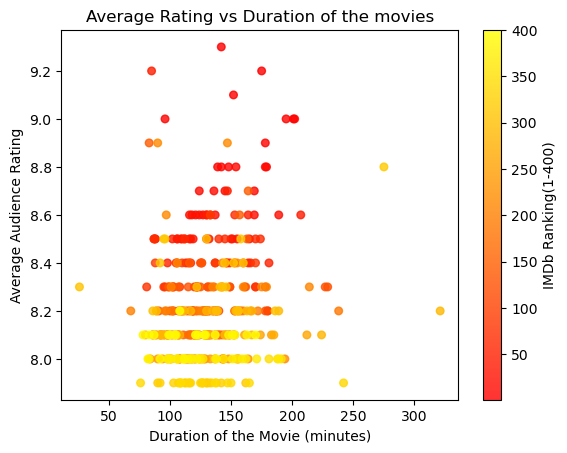

In [24]:
plt.scatter(movies200['runtimeMinutes'], movies200['averageRating'], c=movies200['rank'], cmap='autumn', alpha=0.8, s=30) #check the titles and make colors different for the dots
plt.xlabel('Duration of the Movie (minutes)')
plt.ylabel('Average Audience Rating')
plt.colorbar(label="IMDb Ranking(1-400)")
plt.title("Average Rating vs Duration of the movies")
plt.savefig("ranking vs duration.png")
plt.savefig("averageratingvsduration.png", dpi=300, bbox_inches='tight')

plt.show()


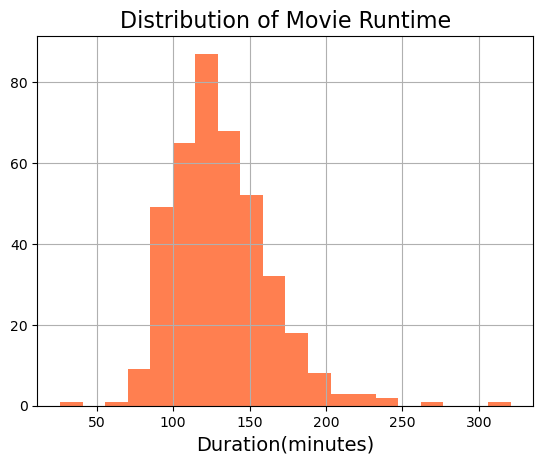

In [14]:
movies200['runtimeMinutes'].hist(bins=20, color='coral')
plt.title("Distribution of Movie Runtime", fontsize=16)
plt.xlabel("Duration(minutes)", fontsize=14)
plt.savefig("Distribution of Movie Runtime.png", dpi=300, bbox_inches='tight')
plt.show()

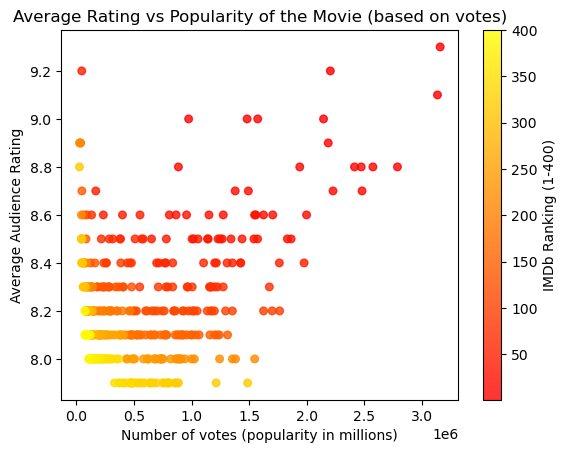

In [15]:
plt.scatter(movies200['numVotes'],movies200['averageRating'], c=movies200['rank'], cmap='autumn', alpha=0.8, s=30) 
plt.xlabel('Number of votes (popularity in millions)')
plt.ylabel('Average Audience Rating')
plt.colorbar(label="IMDb Ranking (1-400)")
plt.title("Average Rating vs Popularity of the Movie (based on votes)")
plt.savefig("Average rating vs amount of votes.png")
plt.show()

In [16]:
genresoveryears= movies200.groupby('genres')['startYear'].sum()

In [18]:
movies200['main_genre'] = movies200['genres'].str.split(',').str[0].str.strip()

In [19]:
genre_year = (
    movies200
    .groupby(['startYear', 'main_genre'])
    .size()
    .reset_index(name='count')
)
genre_pivot = genre_year.pivot(
    index='startYear',
    columns='main_genre',
    values='count'
).fillna(0)

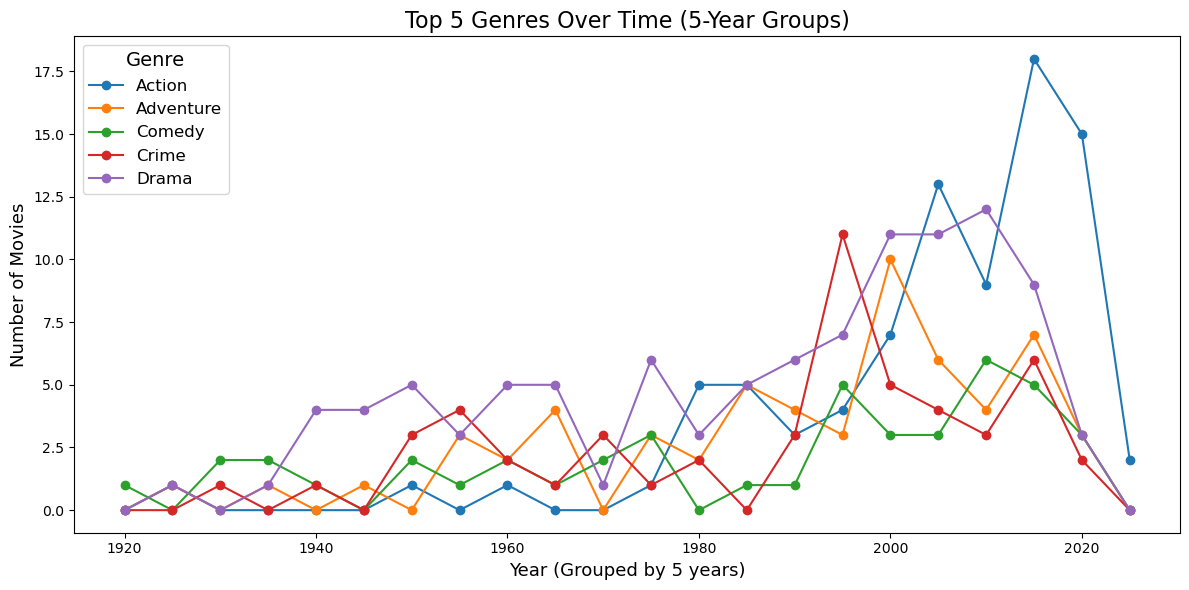

In [21]:
import pandas as pd
import matplotlib.pyplot as plt


movies200['startYear'] = pd.to_numeric(movies200['startYear'], errors='coerce')
movies200 = movies200.dropna(subset=['startYear'])
movies200['startYear'] = movies200['startYear'].astype(int)


movies200['year_5'] = (movies200['startYear'] // 5) * 5


topN = 5
top_genres = movies200['main_genre'].value_counts().head(topN).index
df_top = movies200[movies200['main_genre'].isin(top_genres)]


genre_5yr = (
    df_top
    .groupby(['year_5', 'main_genre'])
    .size()
    .reset_index(name='count')
)


pivot_5yr = genre_5yr.pivot(
    index='year_5',
    columns='main_genre',
    values='count'
).fillna(0)


pivot_5yr.plot(marker='o', figsize=(12,6))
plt.xlabel("Year (Grouped by 5 years)", fontsize=13)
plt.ylabel("Number of Movies", fontsize=13)

plt.title("Top 5 Genres Over Time (5-Year Groups)", fontsize=16)
plt.legend(title="Genre", fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.savefig("Top 5 Genres over time")
plt.show()